# Data Understanding and Preparation
Covers **Stage 1 + 2.1.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided (no change):* `config.py`. 
- *Provided to extend:* `src/data_prep.py` (function stubs). 
- *You build:* this notebook + the report.

Prereqs: `pip install -r requirements.txt`; extract the Kaggle casting dataset under `data/` (train/test → ok_front/def_front).

### 0. Setup

In [1]:
import config
from src import data_prep
# TODO: print config.CLASS_TO_IDX and config.POSITIVE_CLASS to confirm setup


In [4]:
import config
from src import data_prep

# Verify project configuration
print("Class Mapping:", config.CLASS_TO_IDX)
print("Positive Class:", config.POSITIVE_CLASS)

Class Mapping: {'ok_front': 0, 'def_front': 1}
Positive Class: def_front


In [2]:
import sys

print(sys.executable)
print(sys.version)

c:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\.venv\Scripts\python.exe
3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [3]:
import torch
import torchvision
import mlflow
import fastapi
import evidently

KeyError: ~TResult

## **Stage 1.1 — Business & Data Understanding** <font color="red">[5 marks]</font>

- **1.1.1 — Business objective & justification [2]** — *to be done in the report*
- **1.1.2 — Success metric choice (recall/F1 on defects) [2]** — *to be done in the report*
- **1.1.3 — Dataset structure & class understanding [1]**

**Objective:** Understand the problem + dataset and name the right metric.

**Implement in:** this notebook (+ src/data_prep.find_data_root, list_images)

**Inputs → Outputs:** data/ images → counts + class distribution per split

**TODO:** locate the data root; count images per class per split; plot the distribution; state that defect = positive class and recall-on-defects (not accuracy) is the headline metric.

**Document here:** 1.1.1/1.1.2 in the report; 1.1.3 here (dataset structure).

In [ ]:
# TODO 1.1.3: root = data_prep.find_data_root(); count + plot class distribution by split


In [7]:
from pathlib import Path
import config

print("DATA_DIR:", config.DATA_DIR)
print("\nContents of DATA_DIR:")

for item in Path(config.DATA_DIR).iterdir():
    print(item)

DATA_DIR: C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data

Contents of DATA_DIR:
C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data


In [15]:
import importlib
from src import data_prep

# Reload project modules after making changes in src/
importlib.reload(data_prep)

<module 'src.data_prep' from 'c:\\Users\\Abhinav\\Capstone_MLOps\\MLOps_2_Starter\\src\\data_prep.py'>

In [16]:
root = data_prep.find_data_root()

print(root)

C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data


In [17]:
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

# Locate dataset
root = data_prep.find_data_root()

# Load image paths
train_images = data_prep.list_images(root / "train")
test_images = data_prep.list_images(root / "test")

# Count class distribution
train_counts = Counter(label for _, label in train_images)
test_counts = Counter(label for _, label in test_images)

print("=" * 60)
print("Dataset Summary")
print("=" * 60)

print(f"Dataset Root : {root}")
print(f"Positive Class : {config.POSITIVE_CLASS}")

print("\nTraining Split")
for cls_name, cls_idx in config.CLASS_TO_IDX.items():
    print(f"{cls_name:<12}: {train_counts.get(cls_idx, 0)}")

print("\nTesting Split")
for cls_name, cls_idx in config.CLASS_TO_IDX.items():
    print(f"{cls_name:<12}: {test_counts.get(cls_idx, 0)}")

Dataset Summary
Dataset Root : C:\Users\Abhinav\Capstone_MLOps\MLOps_2_Starter\data\casting_data
Positive Class : def_front

Training Split
ok_front    : 40
def_front   : 40

Testing Split
ok_front    : 40
def_front   : 40


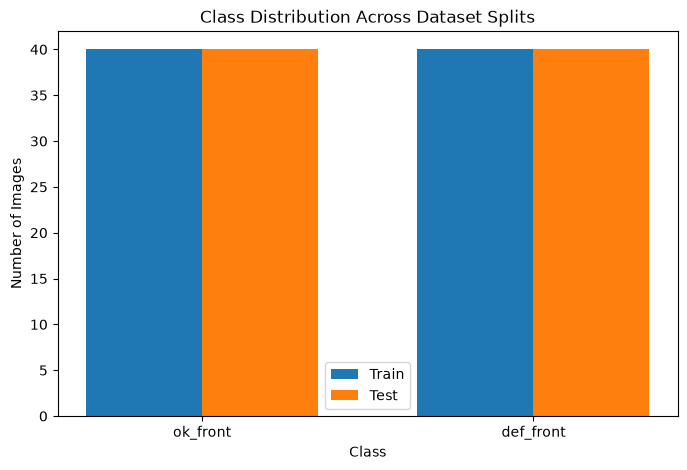

In [18]:
labels = list(config.CLASS_TO_IDX.keys())
indices = list(config.CLASS_TO_IDX.values())

train_values = [train_counts.get(i, 0) for i in indices]
test_values = [test_counts.get(i, 0) for i in indices]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width / 2, train_values, width, label="Train")
plt.bar(x + width / 2, test_values, width, label="Test")

plt.xticks(x, labels)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution Across Dataset Splits")
plt.legend()

plt.show()

Dataset Understanding

- The dataset contains two classes:
  - **ok_front** – Non-defective casting
  - **def_front** – Defective casting

- The **positive class** is **def_front**.

- Since missing a defective casting is more costly than falsely flagging a good casting, **Recall for the defective class** is selected as the primary evaluation metric. Accuracy alone may be misleading, especially if class distributions become imbalanced.

## **Stage 1.2 — Data Quality Validation** <font color="red">[5 marks]</font>

- **1.2.1 — Corrupt-file & image-dimension checks [2]**
- **1.2.2 — Duplicate detection (hashing) — leakage guard [2]**
- **1.2.3 — Class distribution + pass/fail report [1]**

**Objective:** Programmatically validate image quality before any split.

**Implement in:** src/data_prep.validate_quality

**Inputs → Outputs:** data root → a pass/fail report dict (corrupt, duplicates, dimensions, distribution)

**TODO:** check missing/corrupt files (Image.verify) and dimensions (1.2.1); detect DUPLICATE images via md5/hash (1.2.2); quantify class balance + print a pass/fail report (1.2.3); expect ~7,348 images, ~64 duplicates.

**Document here:** the quality report + why duplicate detection prevents train/test leakage.

In [ ]:
# TODO 1.2.1-1.2.3: qc = data_prep.validate_quality(root); print(qc['total_images'], qc['passed'])


## **Stage 1.3 — Dataset Versioning & Metadata** <font color="red">[5 marks]</font>

- **1.3.1 — Reproducible, stratified train/val/test split [3]**
- **1.3.2 — Split snapshot + metadata.json (versioning) [2]**

**Objective:** Create reproducible, versioned splits.

**Implement in:** src/data_prep.build_splits

**Inputs → Outputs:** data root + version id → train/val/test file lists + metadata.json

**TODO:** make a STRATIFIED train/val/test split (seed 42) (1.3.1); snapshot the file lists + write metadata.json (version id, date, class defs, split sizes, seed) (1.3.2).

**Document here:** the split sizes + the metadata record.

In [ ]:
# TODO 1.3.1-1.3.2: meta = data_prep.build_splits(root, 'v1'); print(meta['split_info'])


## **Stage 1.4 — EDA & Methodology Design** <font color="red">[5 marks]</font>

- **1.4.1 — Image-characteristic EDA [3]** — *to be done in this notebook and the report*
- **1.4.2 — End-to-end MLOps workflow design [2]** — *to be done in the report*

**Objective:** Explore image characteristics that motivate preprocessing + drift features.

**Implement in:** this notebook (+ src/data_prep.image_features)

**Inputs → Outputs:** sample images → a feature table (brightness/contrast/edge/sharpness/dark-ratio) by class

**TODO:** show a sample grid (OK vs Defective) + per-class feature means (1.4.1); in the report, design the end-to-end MLOps workflow (1.4.2).

**Document here:** an interpretation cell (1.4.1) + the workflow design in the report (1.4.2).

In [ ]:
# TODO 1.4.1: sample-image grid; per-class image_features means


## **Stage 2.1 — Preprocessing & Augmentation** <font color="red">[6 marks]</font>

- **2.1.1 — Convert greyscale image to 3-channel RGB, resize 224, ImageNet normalise [3]**
- **2.1.2 — Train-only augmentation (val/test none) [3]**

**Objective:** Build transforms that match the pretrained ResNet18 backbone.

**Implement in:** src/data_prep.get_transforms

**Inputs → Outputs:** a PIL image → a (3,224,224) normalised tensor; train transform adds augmentation

**TODO:** Convert greyscale image to 3-channel RGB, Resize 224, ImageNet normalise (2.1.1); train-time augmentation (flip/rotation/translate/colour jitter) with val/test NO augmentation (2.1.2).

**Document here:** a before/after visualisation of the transforms.

In [ ]:
# TODO 2.1.1-2.1.2: tf=data_prep.get_transforms(train=True); verify a sample tensor is (3,224,224)


---
**Outputs feed Stage 2.2+** in `Model_Development_and_Tracking.ipynb` (the versioned splits + transforms are reused to train the model).